   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

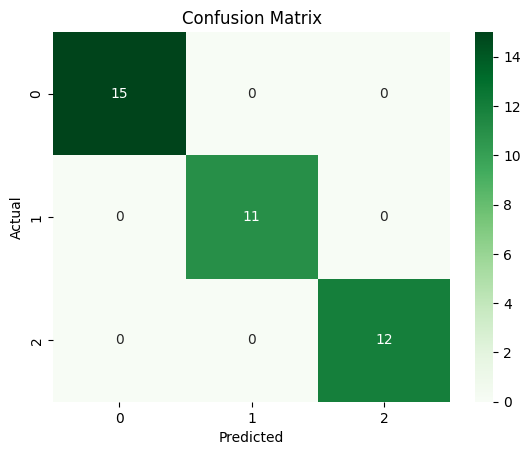

In [1]:
# =========================================
# Data Analytics III - Naive Bayes (Iris)
# =========================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# =========================================
# 2. Load Dataset
# =========================================

df = pd.read_csv("Iris.csv")   # or Iris(1).csv

print(df.head())
print("\nDataset Info:\n")
print(df.info())

# =========================================
# 3. Preprocessing
# =========================================

# Drop unnecessary column if present
if 'Id' in df.columns:
    df.drop(columns=['Id'], inplace=True)

# Features and target
X = df.drop("Species", axis=1)
y = df["Species"]

# =========================================
# 4. Train-Test Split
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# =========================================
# 5. Train Naive Bayes Model
# =========================================

model = GaussianNB()
model.fit(X_train, y_train)

# =========================================
# 6. Prediction
# =========================================

y_pred = model.predict(X_test)

# =========================================
# 7. Confusion Matrix
# =========================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)

# =========================================
# 8. Metrics
# =========================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
error_rate = 1 - accuracy

print("\nAccuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

# =========================================
# 9. Visualization
# =========================================

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [2]:
# Convert to binary (Setosa vs Others)

y_binary = y.apply(lambda x: 1 if x == "Iris-setosa" else 0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.25, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

print("\nTN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)


TN: 23
FP: 0
FN: 0
TP: 15
